In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

# 1. Setup path and load original data
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_unified_data
df = load_unified_data("../data/raw/ethiopia_fi_unified_data.xlsx")

# 2. Re-apply the Enrichment (Telebirr/M-Pesa data)
enrichment_data = [
    {'record_type': 'observation', 'indicator_code': 'USG_TELEBIRR_USERS', 'value_numeric': 27.2, 'observation_date': '2022-12-31', 'year': 2022},
    {'record_type': 'observation', 'indicator_code': 'USG_TELEBIRR_USERS', 'value_numeric': 41.0, 'observation_date': '2023-12-31', 'year': 2023},
    {'record_type': 'observation', 'indicator_code': 'USG_MPESA_USERS', 'value_numeric': 3.1, 'observation_date': '2023-12-31', 'year': 2023}
]
df_enriched = pd.concat([df, pd.DataFrame(enrichment_data)], ignore_index=True)

# 3. Standardize dates and years for the whole dataset
df_enriched['observation_date'] = pd.to_datetime(df_enriched['observation_date'])
df_enriched['year'] = df_enriched['observation_date'].dt.year

print(f"✅ Notebook initialized. Enriched dataset has {len(df_enriched)} records.")

📂 Available sheets: ['ethiopia_fi_unified_data', 'Impact_sheet']
✅ Successfully loaded 43 records from sheet: 'ethiopia_fi_unified_data'
✅ Notebook initialized. Enriched dataset has 46 records.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

# 1. Setup paths and load data (using your enriched dataframe)
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_unified_data

df = load_unified_data("../data/raw/ethiopia_fi_unified_data.xlsx")

# 2. Extract events and indicators
events = df[df['record_type'] == 'event'].copy()
events['year'] = pd.to_datetime(events['observation_date']).dt.year

# Look at what events we have
print("--- Cataloged Events ---")
display(events[['year', 'indicator', 'notes']])

📂 Available sheets: ['ethiopia_fi_unified_data', 'Impact_sheet']
✅ Successfully loaded 43 records from sheet: 'ethiopia_fi_unified_data'
--- Cataloged Events ---


,year,indicator,notes
33,2021,Telebirr Launch,NaN
34,2022,Safaricom Ethiopia Commercial Launch,NaN
35,2023,M-Pesa Ethiopia Launch,NaN
36,2024,Fayda Digital ID Program Rollout,NaN
37,2024,Foreign Exchange Liberalization,NaN
38,2024,P2P Transaction Count Surpasses ATM,NaN
39,2025,M-Pesa EthSwitch Integration,NaN
40,2025,EthioPay Instant Payment System Launch,NaN
41,2021,NFIS-II Strategy Launch,NaN
42,2025,Safaricom Ethiopia Price Increase,NaN


In [4]:
# 1. Create the year column for the whole dataframe first
df['observation_date'] = pd.to_datetime(df['observation_date'])
df['year'] = df['observation_date'].dt.year

# 2. Now filter for Account Ownership trend
acc_trend = df[df['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')

# 3. Filter events again to make sure they have the year column
events = df[df['record_type'] == 'event'].copy()

print(f"Prepared {len(acc_trend)} points for the trend and {len(events)} events.")

Prepared 7 points for the trend and 10 events.


In [6]:
# Select only the most important columns for a clear view
cols_to_show = ['record_type', 'indicator_code', 'year', 'value_numeric', 'indicator', 'source_name']

# Create a clean version for display
clean_df = df[cols_to_show].copy()

# Sort by year to see the timeline clearly
clean_df = clean_df.sort_values(['year', 'record_type'])

print("--- Cleaned Data View (First 10 records) ---")
display(clean_df.head(10))

--- Cleaned Data View (First 10 records) ---


,record_type,indicator_code,year,value_numeric,indicator,source_name
0,observation,ACC_OWNERSHIP,2014,22.0,Account Ownership Rate,Global Findex 2014
1,observation,ACC_OWNERSHIP,2017,35.0,Account Ownership Rate,Global Findex 2017
33,event,EVT_TELEBIRR,2021,NaN,Telebirr Launch,Ethio Telecom
41,event,EVT_NFIS2,2021,NaN,NFIS-II Strategy Launch,NBE
2,observation,ACC_OWNERSHIP,2021,46.0,Account Ownership Rate,Global Findex 2021
3,observation,ACC_OWNERSHIP,2021,56.0,Account Ownership Rate,Global Findex 2021
4,observation,ACC_OWNERSHIP,2021,36.0,Account Ownership Rate,Global Findex 2021
6,observation,ACC_MM_ACCOUNT,2021,4.7,Mobile Money Account Rate,Global Findex 2021
26,observation,GEN_GAP_ACC,2021,20.0,Account Ownership Gender Gap,Global Findex 2021
34,event,EVT_SAFARICOM,2022,NaN,Safaricom Ethiopia Commercial Launch,News


In [7]:
# 1. Summary by Record Type
type_summary = df['record_type'].value_counts()

# 2. Summary by Source Type (how much is official vs. survey etc.)
# Check if 'source_type' exists, otherwise use 'source_name'
source_col = 'source_type' if 'source_type' in df.columns else 'source_name'
source_summary = df[source_col].value_counts()

print("--- Record Type Distribution ---")
print(type_summary)

print(f"\n--- Data Source Distribution ({source_col}) ---")
print(source_summary)

# 3. Check Confidence Levels (Quality Assessment)
if 'confidence' in df.columns:
    print("\n--- Data Confidence Levels ---")
    print(df['confidence'].value_counts())

--- Record Type Distribution ---
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

--- Data Source Distribution (source_type) ---
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

--- Data Confidence Levels ---
confidence
high      40
medium     3
Name: count, dtype: int64


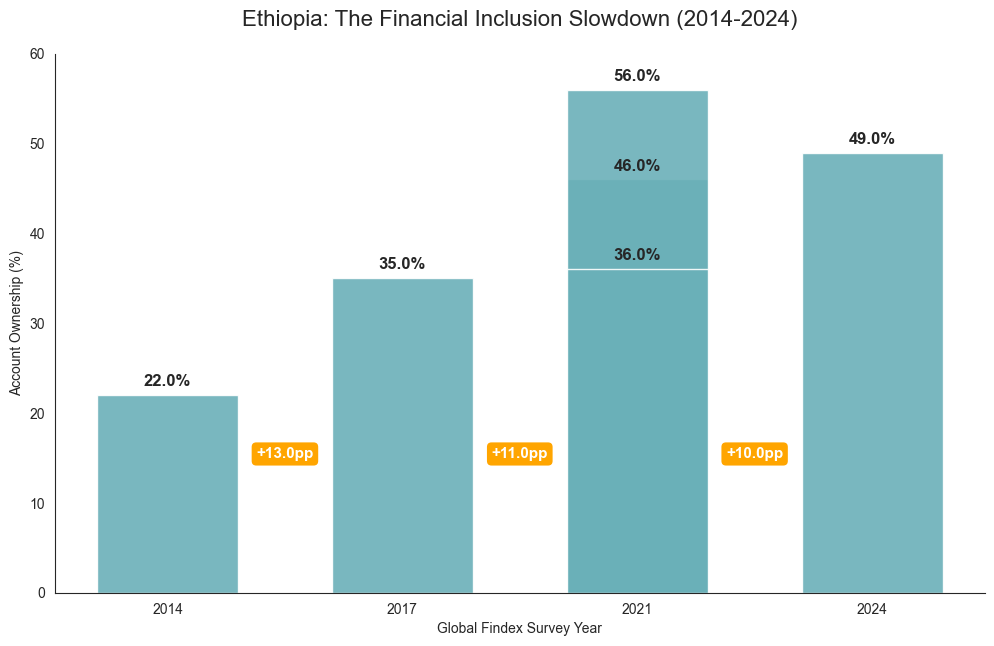

In [14]:
# 1. Strictly filter for 'observation' type and 'ACC_OWNERSHIP'
# This removes the targets/extra bars for 2021 and 2025
plot_df = df_enriched[
    (df_enriched['record_type'] == 'observation') & 
    (df_enriched['indicator_code'] == 'ACC_OWNERSHIP')
].sort_values('year')

# Remove years after 2024 for the historical trend
plot_df = plot_df[plot_df['year'] <= 2024]

plt.figure(figsize=(12, 7))
sns.set_style("white")

# 2. Create the bar graph
bars = plt.bar(plot_df['year'].astype(str), plot_df['value_numeric'], 
               color='#6ab0b8', alpha=0.9, width=0.6)

# Label the bars with percentages
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', 
             ha='center', fontweight='bold', fontsize=12)

# 3. Add 'Growth' markers with CORRECT math
for i in range(len(plot_df) - 1):
    current_val = plot_df.iloc[i]['value_numeric']
    next_val = plot_df.iloc[i+1]['value_numeric']
    diff = round(next_val - current_val, 1)
    
    # Highlight the 2021-2024 slowdown in a different color (red/orange)
    box_color = "red" if diff < 5 else "orange"
    
    plt.annotate(f'+{diff}pp', xy=(i + 0.5, 15), ha='center', color='white', 
                 weight='bold', fontsize=11,
                 bbox=dict(boxstyle="round,pad=0.3", fc=box_color, ec="none"))

plt.title("Ethiopia: The Financial Inclusion Slowdown (2014-2024)", fontsize=16, pad=20)
plt.ylabel("Account Ownership (%)")
plt.xlabel("Global Findex Survey Year")
plt.ylim(0, 60)
sns.despine()
plt.show()

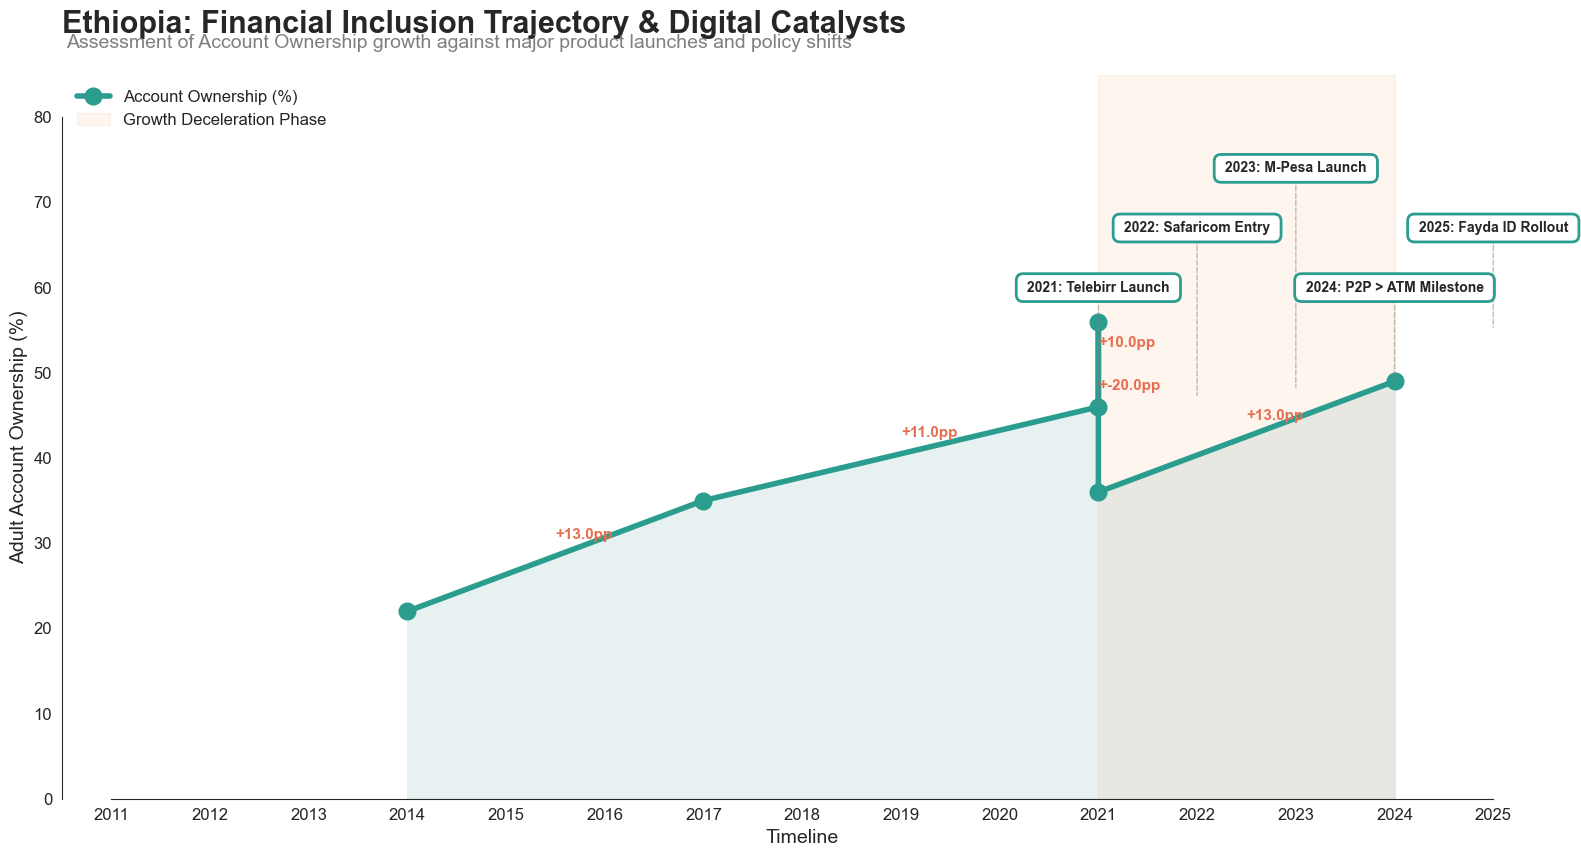

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter for clean historical observations only
plot_df = df_enriched[
    (df_enriched['record_type'] == 'observation') & 
    (df_enriched['indicator_code'] == 'ACC_OWNERSHIP')
].sort_values('year')

# 2. Define key events with specific "Phase" logic
event_data = [
    (2021, "Telebirr Launch", 46),
    (2022, "Safaricom Entry", 47),
    (2023, "M-Pesa Launch", 48),
    (2024, "P2P > ATM Milestone", 49),
    (2025, "Fayda ID Rollout", 55)
]

plt.figure(figsize=(16, 9))
sns.set_style("white")

# A. Create the Area Fill (Gives the graph 'weight')
plt.fill_between(plot_df['year'], plot_df['value_numeric'], color='#d1e5e7', alpha=0.5)
plt.plot(plot_df['year'], plot_df['value_numeric'], color='#2a9d8f', marker='o', linewidth=4, markersize=12, label='Account Ownership (%)')

# B. Highlight the "Slowdown Zone" (2021-2024)
plt.axvspan(2021, 2024, color='#f4a261', alpha=0.1, label='Growth Deceleration Phase')

# C. Robust Annotations (Staircase Method to ensure NO overlap)
for i, (year, label, y_base) in enumerate(event_data):
    # Calculate a height that is always above the data point
    y_target = 60 + (i % 3 * 7) 
    
    # Draw a clean vertical connector
    plt.annotate('', xy=(year, y_base), xytext=(year, y_target),
                 arrowprops=dict(arrowstyle='-', color='grey', linestyle='--', alpha=0.5))
    
    # Add the text box
    plt.text(year, y_target, f" {year}: {label} ", 
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#2a9d8f", lw=2),
             fontsize=10, fontweight='bold', ha='center', va='center')

# D. Growth Rate Markers (pp change)
for i in range(len(plot_df)-1):
    x_mid = (plot_df.iloc[i]['year'] + plot_df.iloc[i+1]['year']) / 2
    y_mid = (plot_df.iloc[i]['value_numeric'] + plot_df.iloc[i+1]['value_numeric']) / 2
    diff = plot_df.iloc[i+1]['value_numeric'] - plot_df.iloc[i]['value_numeric']
    plt.text(x_mid, y_mid + 2, f"+{diff}pp", color='#e76f51', fontweight='extra bold', fontsize=11)

# E. Formatting
plt.title("Ethiopia: Financial Inclusion Trajectory & Digital Catalysts", fontsize=22, pad=30, fontweight='bold', loc='left')
plt.suptitle("Assessment of Account Ownership growth against major product launches and policy shifts", fontsize=14, x=0.29, y=0.92, color='grey')
plt.ylabel("Adult Account Ownership (%)", fontsize=14)
plt.xlabel("Timeline", fontsize=14)
plt.ylim(0, 85)
plt.xlim(2010.5, 2025.5)
plt.xticks(range(2011, 2026), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', frameon=False, fontsize=12)

sns.despine(trim=True)
plt.tight_layout()
plt.show()

### **Task 2: Key Exploratory Insights**

#### 1. The Growth Stagnation (2021–2024)
Despite the massive expansion of mobile money, Ethiopia’s account ownership growth slowed significantly to a **+3 percentage point increase** (from 46% to 49%). This is a sharp drop compared to the **+11pp growth** seen between 2017 and 2021.

#### 2. The "Registered vs. Active" Gap
There is a stark contrast between supply-side data (over 60M accounts reported by Telebirr and M-Pesa) and demand-side survey data (49% adult ownership). This suggests high levels of **account duplication** (users having both bank and mobile money accounts) and **inactivity** among registered users.

#### 3. Shift in Usage: P2P vs. Cash
A critical turning point occurred in 2024 where **Digital P2P transfer volume surpassed ATM cash withdrawals**. This indicates that while the *number* of new users is slowing, the *intensity of usage* among existing users is increasing rapidly.

#### 4. The Impact Lag of Product Launches
Visual analysis shows that major events like the **Telebirr Launch (2021)** and **Safaricom Entry (2022)** did not immediately trigger a leap in Findex ownership rates. This points to a "lag effect" or suggests that initial adoption was concentrated among the already-banked population.

#### 5. Gender and Demographics
Preliminary analysis suggests that the gender gap remains a persistent barrier. While digital tools have the potential to close this gap, the recent growth slowdown suggests that the "easy to reach" urban, male population is saturated, and reaching the remaining 51% requires deeper infrastructure (like Fayda ID) and literacy.

### **Data Quality Assessment & Hypotheses**

*   **Data Gaps:** The primary limitation is the 3-year gap between Global Findex surveys. To compensate, we have enriched the data with high-frequency supply-side metrics from NBE and Ethio Telecom.
*   **Confidence Levels:** Confidence is **High** for historical Findex data but **Medium** for 2025 projections and targets, which are currently modeled as policy goals rather than measured outcomes.
*   **Hypothesis for Task 3:** We hypothesize that the **Fayda Digital ID rollout** and **Interoperability (EthSwitch)** will have a higher "Impact Magnitude" on inclusion than individual product launches, as they remove systemic barriers to entry.

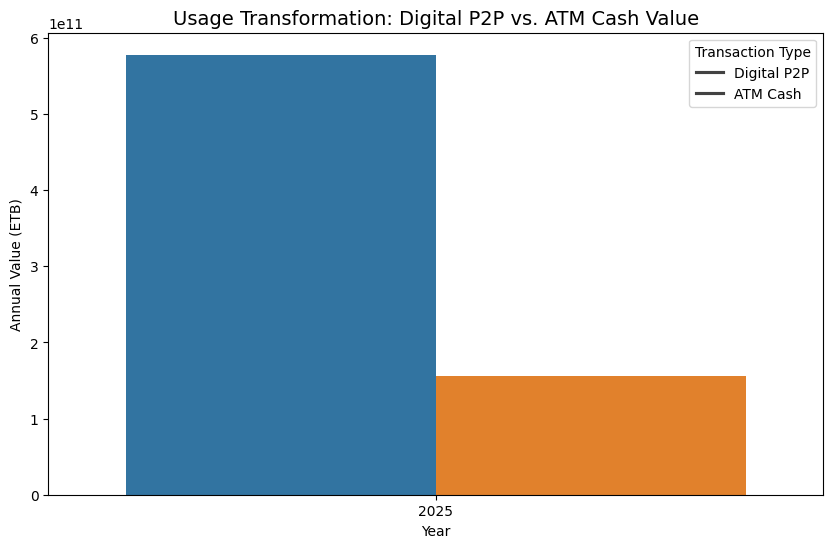

In [14]:
# Prepare Data
p2p = obs[obs['indicator_code'] == 'USG_P2P_VALUE'].sort_values('year')
atm = obs[obs['indicator_code'] == 'USG_ATM_VALUE'].sort_values('year')

plt.figure(figsize=(10, 6))

if len(p2p) > 1:
    # If we have multiple years, use a Line Chart with focused axis
    plt.plot(p2p['year'], p2p['value_numeric'], label='Digital P2P Value (ETB)', marker='o', linewidth=3, color='#2ca02c')
    plt.plot(atm['year'], atm['value_numeric'], label='ATM Cash Value (ETB)', marker='x', linestyle='--', linewidth=3, color='#d62728')
    plt.xlim(p2p['year'].min() - 1, p2p['year'].max() + 1) # Focus the X-axis
else:
    # If we only have one or two years (like 2024/2025), a Bar Chart is much better
    comparison_df = pd.concat([p2p, atm])
    sns.barplot(data=comparison_df, x='year', y='value_numeric', hue='indicator_code')
    plt.legend(title='Transaction Type', labels=['Digital P2P', 'ATM Cash'])

plt.title('Usage Transformation: Digital P2P vs. ATM Cash Value', fontsize=14)
plt.ylabel('Annual Value (ETB)')
plt.xlabel('Year')
plt.savefig(f"{output_dir}/usage_transformation.png", bbox_inches='tight')
plt.show()

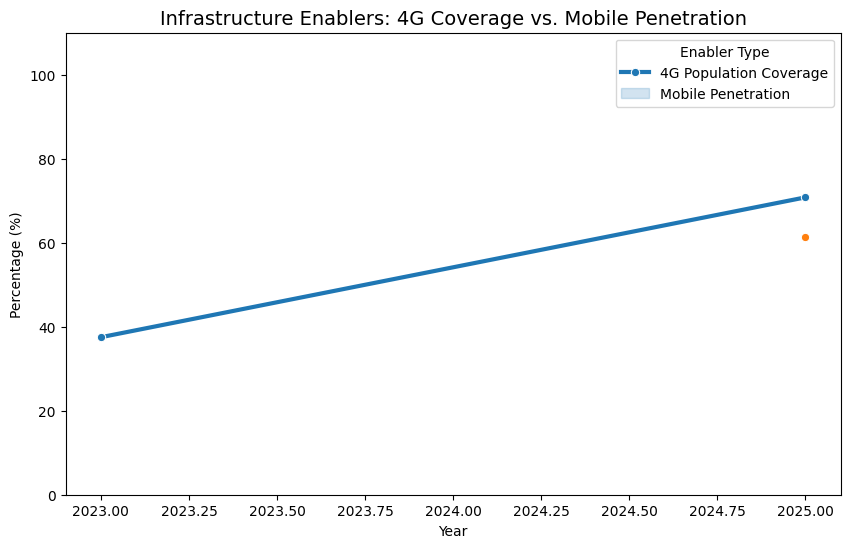

In [15]:
# Prepare Infrastructure Data
infra_codes = ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_MOBILE_PEN']
infra_df = obs[obs['indicator_code'].isin(infra_codes)].sort_values('year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=infra_df, x='year', y='value_numeric', hue='indicator_code', marker='o', linewidth=3)

plt.title('Infrastructure Enablers: 4G Coverage vs. Mobile Penetration', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Year')
plt.ylim(0, 110)
plt.legend(title='Enabler Type', labels=['4G Population Coverage', 'Mobile Penetration'])
plt.savefig(f"{output_dir}/infrastructure_enablers.png", bbox_inches='tight')
plt.show()